What we need to beat : 
DSC_AUC	NSD_AUC	DSC_Final	NSD_Final
3.104	3.232	0.801	0.838

See https://www.codabench.org/competitions/5263/#/pages-tab

In [ ]:
from src.config import config
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
img_dir = os.path.join(config["DATA_DIR"], "3D_val_npz")
gts_dir = os.path.join(config["DATA_DIR"], "3D_val_gt_interactive_seg")
output_dir = os.path.join(config["RESULTS_DIR"], "post_challenge")

challenge_metrics_list = ["DSC_AUC","NSD_AUC","DSC_Final", "NSD_Final"]



In [29]:
evalmetrics_df = pd.read_csv(os.path.join(output_dir, "norateam_metrics.csv"))
evalmetrics_june_df = pd.read_csv(os.path.join(config["RESULTS_DIR"], "simple", "norateam_metrics_2130_cases.csv"))    

In [42]:
print(len(evalmetrics_june_df))
evalmetrics_june_df[challenge_metrics_list].describe()


587


,DSC_AUC,NSD_AUC,DSC_Final,NSD_Final
count,587.000000,587.000000,587.000000,587.000000
mean,2.545110,2.645449,0.652878,0.679189
std,1.304653,1.527331,0.320704,0.380520
min,0.000000,0.000000,0.000000,0.000000
25%,1.722340,1.568769,0.465573,0.439228
50%,3.195087,3.431141,0.810520,0.877072
75%,3.541953,3.787510,0.895413,0.957971
max,3.852928,4.000000,0.963828,1.000000


In [37]:
# keep rows in evalmetrics_june_df that are present in evalmetrics_df
evalmetrics_june_df = evalmetrics_june_df[evalmetrics_june_df["CaseName"].isin(evalmetrics_df["CaseName"])]
len(evalmetrics_june_df)

587

Text(0.5, 0, 'DSC Final')

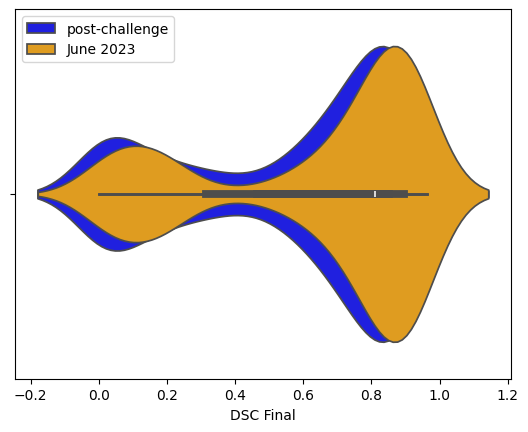

In [38]:
# compare "DSC_AUC" between evalmetrics_df and evalmetrics_june_df
sns.violinplot(data=evalmetrics_df, x="DSC_Final", color="blue", label="post-challenge")
sns.violinplot(data=evalmetrics_june_df, x="DSC_Final", color="orange", label="June 2023")
plt.xlabel("DSC Final")

In [39]:
evalmetrics_df["DSC_Final"].describe()


count    587.000000
mean       0.599422
std        0.322288
min        0.000000
25%        0.314015
50%        0.745552
75%        0.852358
max        0.963085
Name: DSC_Final, dtype: float64

In [40]:
evalmetrics_june_df["DSC_Final"].describe()

count    587.000000
mean       0.652878
std        0.320704
min        0.000000
25%        0.465573
50%        0.810520
75%        0.895413
max        0.963828
Name: DSC_Final, dtype: float64

In [44]:
evalmetrics_df['modality'] = evalmetrics_df['CaseName'].str[:2]
evalmetrics_df[evalmetrics_df['modality'] != "MR" ][challenge_metrics_list].describe()


,DSC_AUC,NSD_AUC,DSC_Final,NSD_Final
count,300.000000,300.000000,300.000000,300.000000
mean,3.087896,3.186136,0.786679,0.814819
std,0.569505,0.635791,0.139775,0.155354
min,0.000000,0.000000,0.000000,0.000000
25%,2.865907,2.944644,0.728834,0.753174
50%,3.242920,3.294929,0.825347,0.842093
75%,3.448015,3.615452,0.875627,0.916751
max,3.852336,4.000000,0.963085,1.000000


In [43]:
evalmetrics_df[challenge_metrics_list].describe()


,DSC_AUC,NSD_AUC,DSC_Final,NSD_Final
count,587.000000,587.000000,587.000000,587.000000
mean,2.331830,2.417309,0.599422,0.623364
std,1.299037,1.449575,0.322288,0.361401
min,0.000000,0.000000,0.000000,0.000000
25%,1.116865,1.125198,0.314015,0.334768
50%,2.917326,3.047210,0.745552,0.782557
75%,3.363054,3.550093,0.852358,0.904059
max,3.852336,4.000000,0.963085,1.000000


Text(0, 0.5, 'DSC Final')

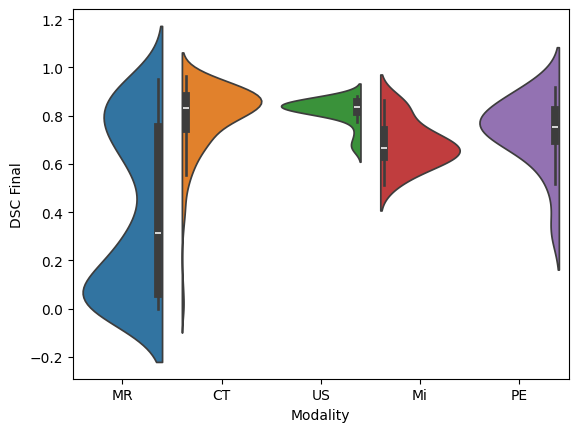

In [47]:
# plot DSC_Final by modality
sns.violinplot(data=evalmetrics_df, x="modality", y="DSC_Final", hue="modality", split=True)
plt.xlabel("Modality")
plt.ylabel("DSC Final")